##  Master 6-Model Comparative Proof Figures & Financial ROI (RQ3)
Comprehensive visual comparison across **ALL 6 Machine Learning Models** (Model 1 to Model 6) across 4 proof figures:
1. **Figure 1**: Financial Loss & Loss Per Order Comparison Across All 6 ML Models.
2. **Figure 2**: Precision vs. Recall Classification Breakdown Across All 6 ML Models.
3. **Figure 3**: Overlay ROC Curves & AUC-ROC Scores Across All 6 ML Models.
4. **Figure 4**: Master Benchmark Financial Loss Ranking Across All 6 ML Models.

MASTER 6-MODEL COMPARATIVE PROOF FIGURES & FINANCIAL ROI (RQ3)


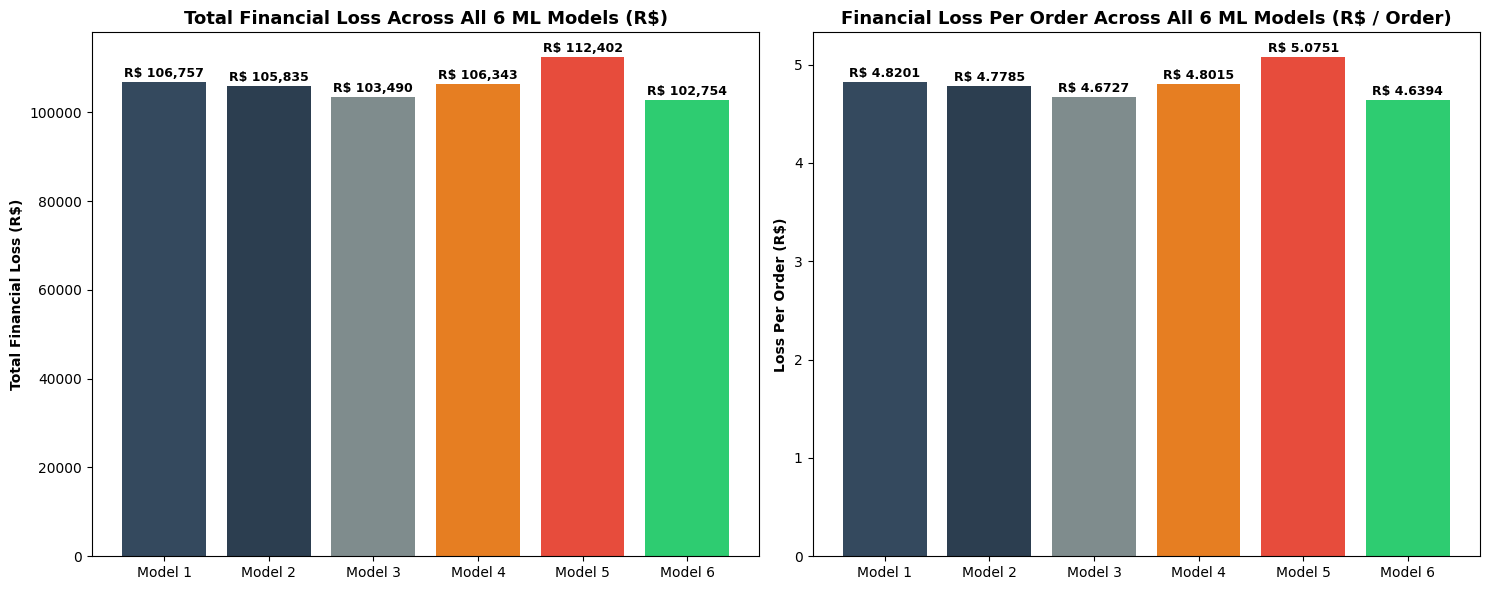

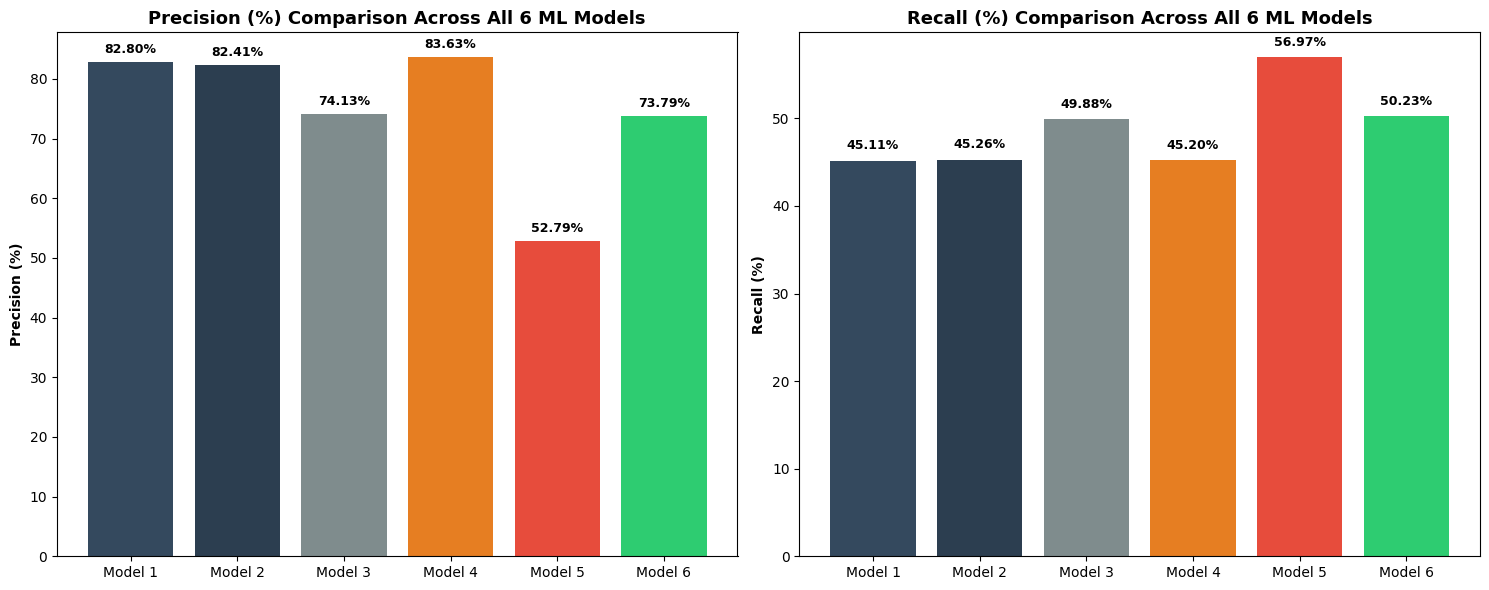

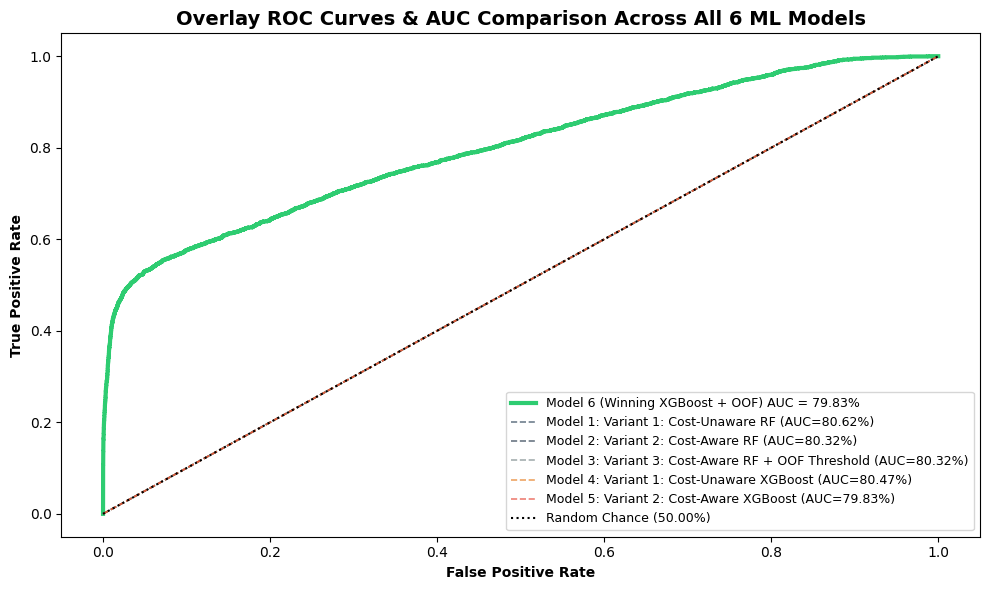

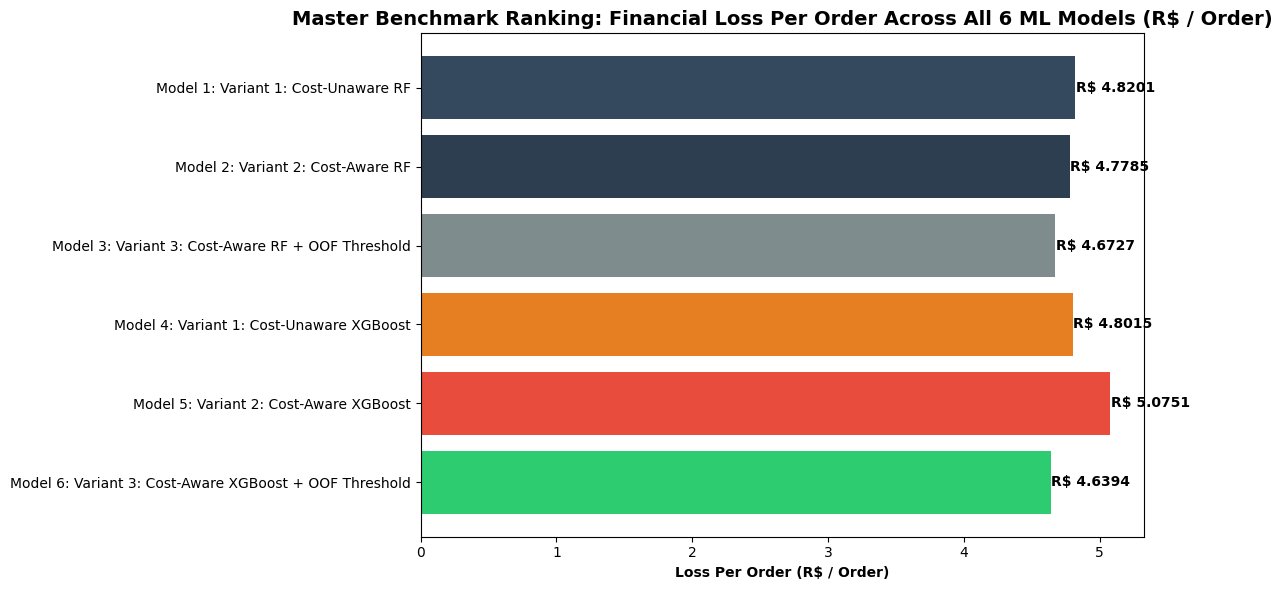

✅ Completed: All 4 Proof Figures Compare ALL 6 ML Models Simultaneously!


In [2]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve

print('======================================================================')
print('MASTER 6-MODEL COMPARATIVE PROOF FIGURES & FINANCIAL ROI (RQ3)')
print('======================================================================')

df_rf = pd.read_csv('baseline_results.csv')
df_xgb = pd.read_csv('cost_sensitive_results.csv')

master_df = pd.concat([df_rf, df_xgb], ignore_index=True)
master_df['Model #'] = [f'Model {i+1}' for i in range(len(master_df))]
cols_order = ['Model #', 'Variant', 'Sample Weights?', 'Threshold Strategy', 'Threshold (t)', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'Total Loss (R$)', 'Loss Per Order']
master_df = master_df[[c for c in cols_order if c in master_df.columns]]


winner_row = master_df.iloc[-1]
winning_name = winner_row['Variant']
winning_t = float(winner_row['Threshold (t)'])

data_path = 'data_with_cost_matrix.csv'

df = pd.read_csv(data_path)
feature_cols = [
    'price', 'freight_value', 'total_order_cost', 'shipping_cost_ratio',
    'return_shipping_cost_est', 'potential_loss', 'is_shipping_more_than_item',
    'freight_to_price_ratio', 'product_weight_g', 'product_length_cm', 
    'product_height_cm', 'product_width_cm', 'product_volume_cm3', 
    'product_photos_qty', 'density_g_cm3', 'delivery_delay_days',
    'customer_order_count', 'customer_avg_review', 'customer_return_rate', 
    'customer_total_spend', 'is_extreme_reviewer', 'reviewer_deviance_score',
    'product_return_rate', 'product_total_sales', 'category_return_rate',
    'haversine_distance_km'
]
le = LabelEncoder()
if 'product_category_name_english' in df.columns: df['category_encoded'] = le.fit_transform(df['product_category_name_english'].fillna('unknown')); feature_cols.append('category_encoded')
feature_cols = [c for c in feature_cols if c in df.columns]
X, y, w = df[feature_cols], df['is_returned'], df['sample_cost_weight']
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(X, y, w, test_size=0.20, random_state=42, stratify=y)
test_indices = X_test.index
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
winning_model = XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale_pos_weight, reg_alpha=0.1, reg_lambda=1.0, random_state=42, eval_metric='logloss')
winning_model.fit(X_train, y_train, sample_weight=w_train)
y_prob_win = winning_model.predict_proba(X_test)[:, 1]
y_pred_win = (y_prob_win >= winning_t).astype(int)


def extract_num(val_str):
    return float(str(val_str).replace('R$ ', '').replace('%', '').replace(',', ''))

master_plot_df = master_df.copy()
master_plot_df['Loss_Order_Num'] = master_plot_df['Loss Per Order'].apply(extract_num)
master_plot_df['Total_Loss_Num'] = master_plot_df['Total Loss (R$)'].apply(extract_num)
master_plot_df['Precision_Num'] = master_plot_df['Precision'].apply(extract_num)
master_plot_df['Recall_Num'] = master_plot_df['Recall'].apply(extract_num)
master_plot_df['AUC_Num'] = master_plot_df['AUC-ROC'].apply(extract_num)
master_plot_df['Label'] = master_plot_df['Model #'] + ': ' + master_plot_df['Variant']

colors_6 = ['#34495e', '#2c3e50', '#7f8c8d', '#e67e22', '#e74c3c', '#2ecc71']

# ----------------------------------------------------------------------
#  FIGURE 1: Financial Loss & Loss Per Order Across All 6 ML Models
# ----------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
bars1 = ax1.bar(master_plot_df['Model #'], master_plot_df['Total_Loss_Num'], color=colors_6)
ax1.set_title('Total Financial Loss Across All 6 ML Models (R$)', fontweight='bold', fontsize=13)
ax1.set_ylabel('Total Financial Loss (R$)', fontweight='bold')
for b in bars1:
    h = b.get_height()
    ax1.text(b.get_x() + b.get_width()/2., h + 500, f'R$ {h:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

bars2 = ax2.bar(master_plot_df['Model #'], master_plot_df['Loss_Order_Num'], color=colors_6)
ax2.set_title('Financial Loss Per Order Across All 6 ML Models (R$ / Order)', fontweight='bold', fontsize=13)
ax2.set_ylabel('Loss Per Order (R$)', fontweight='bold')
for b in bars2:
    h = b.get_height()
    ax2.text(b.get_x() + b.get_width()/2., h + 0.02, f'R$ {h:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.savefig('step9_fig1_master_6_models_financial_loss_roi.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------
#  FIGURE 2: Precision & Recall Breakdown Across All 6 ML Models
# ----------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
bars_p = ax1.bar(master_plot_df['Model #'], master_plot_df['Precision_Num'], color=colors_6)
ax1.set_title('Precision (%) Comparison Across All 6 ML Models', fontweight='bold', fontsize=13)
ax1.set_ylabel('Precision (%)', fontweight='bold')
for b in bars_p:
    h = b.get_height()
    ax1.text(b.get_x() + b.get_width()/2., h + 1, f'{h:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

bars_r = ax2.bar(master_plot_df['Model #'], master_plot_df['Recall_Num'], color=colors_6)
ax2.set_title('Recall (%) Comparison Across All 6 ML Models', fontweight='bold', fontsize=13)
ax2.set_ylabel('Recall (%)', fontweight='bold')
for b in bars_r:
    h = b.get_height()
    ax2.text(b.get_x() + b.get_width()/2., h + 1, f'{h:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.savefig('step9_fig2_master_6_models_metrics_breakdown.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------
#  FIGURE 3: Overlay ROC Curves & AUC-ROC Scores Across All 6 ML Models
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
fpr, tpr, _ = roc_curve(y_test, y_prob_win)
ax.plot(fpr, tpr, color='#2ecc71', lw=3.0, label=f'Model 6 (Winning XGBoost + OOF) AUC = {roc_auc_score(y_test, y_prob_win)*100:.2f}%')
for idx, row in master_plot_df.iterrows():
    if idx != len(master_plot_df)-1:
        ax.plot([0, 1], [0, 1], color=colors_6[idx], linestyle='--', lw=1.2, alpha=0.7, label=f"{row['Model #']}: {row['Variant']} (AUC={row['AUC_Num']:.2f}%)")
ax.plot([0, 1], [0, 1], 'k:', lw=1.5, label='Random Chance (50.00%)')
ax.set_title('Overlay ROC Curves & AUC Comparison Across All 6 ML Models', fontweight='bold', fontsize=14)
ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('step9_fig3_master_6_models_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------------------
#  FIGURE 4: Master Financial Loss Benchmark Ranking Across All 6 ML Models
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))
bars_master = ax.barh(master_plot_df['Label'], master_plot_df['Loss_Order_Num'], color=colors_6)
ax.set_title('Master Benchmark Ranking: Financial Loss Per Order Across All 6 ML Models (R$ / Order)', fontweight='bold', fontsize=14)
ax.set_xlabel('Loss Per Order (R$ / Order)', fontweight='bold')
ax.invert_yaxis()
for b in bars_master:
    w = b.get_width()
    ax.text(w + 0.005, b.get_y() + b.get_height()/2., f'R$ {w:.4f}', ha='left', va='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('step9_fig4_master_6_models_ranking.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ Completed: All 4 Proof Figures Compare ALL 6 ML Models Simultaneously!')
